# Text Classification - Deep Learning (Final Valid Pipeline from Multi-Label Data)

Notebook ini mulai dari dataset peer feedback **multi-label**, melakukan eksplorasi dataset, mentransformasikannya menjadi **single-label** dengan **semantic priority-based label transformation**, lalu menjalankan eksperimen DL yang valid, memakai shared split yang sama dengan eksperimen ML, dan menghasilkan Top-5 model, confusion matrix, error analysis, serta **priority-order ablation experiment** untuk menjawab komentar reviewer.

## Alur evaluasi

1. Dataset multi-label dibersihkan dan dieksplorasi.
2. Label diubah menjadi single label dengan prioritas utama **Problem > Suggestion > Appreciation > Neutral**.
3. Dataset hasil transformasi dibagi menjadi **outer train** dan **outer test** secara stratified, memakai shared split yang sama dengan eksperimen ML.
4. Model selection dilakukan hanya pada bagian training.
5. Model terbaik direfit pada outer train dan dievaluasi satu kali pada held-out test.
6. Untuk menjawab reviewer, dilakukan **priority-order ablation experiment** dengan melatih ulang arsitektur terbaik pada minimal satu urutan prioritas alternatif, memakai split dan protokol evaluasi yang sama.

In [1]:

%matplotlib inline

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import os
import re
import gc
import json
import time
import random
import pickle
import warnings
import contextlib
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing import sequence

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

try:
    import fasttext
    FASTTEXT_IMPORT_OK = True
except Exception as e:
    FASTTEXT_IMPORT_OK = False
    fasttext = None
    print(f"fasttext import unavailable: {e}")

from keras import backend as K

tqdm.pandas()
print("TensorFlow:", tf.__version__)

I0000 00:00:1782474555.292227 2401775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782474557.282815 2401775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [3]:

# =========================
# Parameters
# =========================
TEXT = "text"
LABEL = "text_category"
MULTILABEL_LABEL_COLS = ["Problem", "Suggestion", "Appreciation", "Neutral"]
PRIMARY_PRIORITY_ORDER = ["Problem", "Suggestion", "Appreciation", "Neutral"]
PRIORITY_ORDER = PRIMARY_PRIORITY_ORDER
PRIORITY_MAP = {label: len(PRIORITY_ORDER) - idx for idx, label in enumerate(PRIORITY_ORDER)}

# Ablation settings requested by reviewer.
# The primary order is compared with alternative orderings while keeping the same data, split,
# selected architecture, training protocol, and held-out test set.
RUN_PRIORITY_ORDER_ABLATION = True
PRIORITY_ABLATION_ORDERS = {
    "primary_semantic": PRIMARY_PRIORITY_ORDER,
    # Alternative 1: tests whether actionable suggestions should override problem statements.
    "alternative_actionability_first": ["Suggestion", "Problem", "Appreciation", "Neutral"],
    # Alternative 2: tests whether explicit positive feedback should be prioritized.
    "alternative_appreciation_first": ["Appreciation", "Suggestion", "Problem", "Neutral"],
}
ABLATION_RETRAIN_PRIMARY = False

ROOT_DIR = "/home/jupyter-sigitpurnomo/jupyter-data/ysp-research/pr-icitcom"
MULTILABEL_DATA_PATH = os.path.join(ROOT_DIR, "data/peer_review_masdig_fin_combined_100_4_labels.csv")
STOPWORD_PATH = "/home/jupyter-sigitpurnomo/research/peer-code-review/stopword.txt"
FASTTEXT_PATH = "/home/jupyter-sigitpurnomo/research/peer-code-review/cc.id.300.bin"
RUN_NAME_PREFIX = "model_selection_singleclasses_dl_from_multilabel_priority"

OUTER_TEST_SIZE = 0.20
SELECTION_VALID_SIZE = 0.20
CV_SPLITS = 5
MAX_LEN = 300
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 4
NUM_WORDS = None
USE_PRETRAINED = True
USE_CLASS_WEIGHTS = False
SAVE_PLOTS = True

SHARED_SPLIT_NAMESPACE = "multilabel_priority_singlelabel_basicclean_v1"
SHARED_SPLIT_GROUP = "shared_splits_singleclasses"
SHARED_SPLIT_ID = f"{SHARED_SPLIT_NAMESPACE}_seed{SEED}_test{int(OUTER_TEST_SIZE*100)}_valid{int(SELECTION_VALID_SIZE*100)}"
SHARED_SPLIT_DIR = os.path.join(ROOT_DIR, SHARED_SPLIT_GROUP, SHARED_SPLIT_ID)
os.makedirs(SHARED_SPLIT_DIR, exist_ok=True)

MODEL_FLAGS = {
    "Shallow_NN_WE": False,
    "Deep_NN_WE": False,
    "Deep_NN_var1_WE": False,
    "Deep_NN_var2_WE": False,
    "RNN_WE": True,
    "CNN_WE": True,
    "LSTM_WE": True,
    "CNN_LSTM_WE": True,
    "CNN_GRU_WE": True,
    "GRU_WE": True,
    "BiRNN_WE": True,
    "BiLSTM_WE": True,
    "BiGRU_WE": True,
    "RCNN_WE": True,
    "RCNN_var1_WE": True,
    "RCNN_var2_WE": True,
    "RCNN_var3_WE": True,
    "Transformers_WE": True,
}

RUN_ID = f"{RUN_NAME_PREFIX}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = os.path.join(ROOT_DIR, RUN_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Shared split dir:", SHARED_SPLIT_DIR)
print("Multi-label source:", MULTILABEL_DATA_PATH)
print("Priority order:", PRIORITY_ORDER)
print("Priority ablation orders:", PRIORITY_ABLATION_ORDERS)


OUTPUT_DIR: /home/jupyter-sigitpurnomo/jupyter-data/ysp-research/pr-icitcom/model_selection_singleclasses_dl_from_multilabel_priority_20260626_184918
Shared split dir: /home/jupyter-sigitpurnomo/jupyter-data/ysp-research/pr-icitcom/shared_splits_singleclasses/multilabel_priority_singlelabel_basicclean_v1_seed42_test20_valid20
Multi-label source: /home/jupyter-sigitpurnomo/jupyter-data/ysp-research/pr-icitcom/data/peer_review_masdig_fin_combined_100_4_labels.csv
Priority order: ['Problem', 'Suggestion', 'Appreciation', 'Neutral']
Priority ablation orders: {'primary_semantic': ['Problem', 'Suggestion', 'Appreciation', 'Neutral'], 'alternative_actionability_first': ['Suggestion', 'Problem', 'Appreciation', 'Neutral'], 'alternative_appreciation_first': ['Appreciation', 'Suggestion', 'Problem', 'Neutral']}


In [4]:

# Save run configuration for traceability
run_config = {
    "TEXT": TEXT,
    "LABEL": LABEL,
    "MULTILABEL_DATA_PATH": MULTILABEL_DATA_PATH,
    "MULTILABEL_LABEL_COLS": MULTILABEL_LABEL_COLS,
    "PRIMARY_PRIORITY_ORDER": PRIMARY_PRIORITY_ORDER,
    "PRIORITY_ORDER": PRIORITY_ORDER,
    "PRIORITY_MAP": PRIORITY_MAP,
    "RUN_PRIORITY_ORDER_ABLATION": RUN_PRIORITY_ORDER_ABLATION,
    "PRIORITY_ABLATION_ORDERS": PRIORITY_ABLATION_ORDERS,
    "ABLATION_RETRAIN_PRIMARY": ABLATION_RETRAIN_PRIMARY,
    "STOPWORD_PATH": STOPWORD_PATH,
    "FASTTEXT_PATH": FASTTEXT_PATH,
    "OUTER_TEST_SIZE": OUTER_TEST_SIZE,
    "SELECTION_VALID_SIZE": SELECTION_VALID_SIZE,
    "CV_SPLITS": CV_SPLITS,
    "MAX_LEN": MAX_LEN,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
    "NUM_WORDS": NUM_WORDS,
    "USE_PRETRAINED": USE_PRETRAINED,
    "USE_CLASS_WEIGHTS": USE_CLASS_WEIGHTS,
    "MODEL_FLAGS": MODEL_FLAGS,
    "SEED": SEED,
    "SHARED_SPLIT_ID": SHARED_SPLIT_ID,
    "SHARED_SPLIT_DIR": SHARED_SPLIT_DIR,
}
with open(os.path.join(OUTPUT_DIR, "run_config.json"), "w") as f:
    json.dump(run_config, f, indent=2)


## Load, explore, and transform the multi-label dataset

In [5]:

def remove_upper_case(text):
    if pd.isna(text):
        return ""
    sentences = str(text).split("\n")
    new_sentences = []
    for sent in sentences:
        words = sent.split()
        stripped = [w.title() if w.isupper() else w for w in words]
        new_sentences.append(" ".join(stripped))
    return "\n".join(new_sentences)


def remove_URL(text):
    if pd.isna(text):
        return ""
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'', str(text))


def remove_html(text):
    if pd.isna(text):
        return ""
    html = re.compile(r'<.*?>')
    return html.sub(r'', str(text))


def remove_emoji(text):
    if pd.isna(text):
        return ""
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub(r'', str(text))


def basic_clean(text):
    text = remove_upper_case(text)
    text = remove_URL(text)
    text = remove_html(text)
    text = remove_emoji(text)
    return str(text).strip()


def coerce_binary_multilabel_columns(df, label_cols):
    out = df.copy()
    for col in label_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int).clip(0, 1)
    return out


def active_labels_from_row(row, label_cols):
    return [label for label in label_cols if int(row[label]) == 1]


def semantic_priority_transform(df, text_col, label_cols, priority_map, output_label_col):
    out = coerce_binary_multilabel_columns(df, label_cols)
    out["active_labels"] = out.apply(lambda row: active_labels_from_row(row, label_cols), axis=1)
    out["num_active_labels"] = out["active_labels"].apply(len)
    out["is_multilabel"] = out["num_active_labels"] > 1
    out["active_labels_str"] = out["active_labels"].apply(lambda labels: "|".join(labels))
    out[output_label_col] = out["active_labels"].apply(
        lambda labels: np.nan if len(labels) == 0 else max(labels, key=lambda l: priority_map[l])
    )
    out = out.dropna(subset=[output_label_col]).copy()
    out.reset_index(drop=True, inplace=True)
    return out


def load_or_create_shared_splits(dataset, label_col, seed, test_size, valid_size, split_dir):
    split_assignment_path = os.path.join(split_dir, "split_assignments.csv")
    train_path = os.path.join(split_dir, "train_split.csv")
    valid_path = os.path.join(split_dir, "valid_split.csv")
    test_path = os.path.join(split_dir, "test_split.csv")
    cleaned_dataset_path = os.path.join(split_dir, "dataset_basic_clean.csv")

    expected_row_ids = set(dataset["row_id"].tolist())

    if os.path.exists(split_assignment_path):
        split_df = pd.read_csv(split_assignment_path)
        required_cols = {"row_id", "split"}
        if not required_cols.issubset(split_df.columns):
            raise ValueError(f"Split file is missing required columns: {required_cols}")
        file_row_ids = set(split_df["row_id"].tolist())
        if file_row_ids != expected_row_ids:
            raise ValueError(
                "Existing shared split file does not match the current cleaned dataset. "
                f"Expected {len(expected_row_ids)} row_ids, found {len(file_row_ids)}."
            )
    else:
        outer_train_ids, test_ids = train_test_split(
            dataset["row_id"].values,
            test_size=test_size,
            random_state=seed,
            stratify=dataset[label_col].values,
        )

        outer_train_df = dataset[dataset["row_id"].isin(outer_train_ids)].copy()
        train_ids, valid_ids = train_test_split(
            outer_train_df["row_id"].values,
            test_size=valid_size,
            random_state=seed,
            stratify=outer_train_df[label_col].values,
        )

        train_id_set = set(train_ids)
        valid_id_set = set(valid_ids)
        split_df = pd.DataFrame({
            "row_id": dataset["row_id"].values,
            "split": dataset["row_id"].map(
                lambda rid: "train" if rid in train_id_set else ("valid" if rid in valid_id_set else "test")
            )
        })
        split_df.to_csv(split_assignment_path, index=False)
        dataset.to_csv(cleaned_dataset_path, index=False)

    split_df = pd.read_csv(split_assignment_path)
    split_df["split"] = pd.Categorical(split_df["split"], categories=["train", "valid", "test"], ordered=True)
    merged = dataset.merge(split_df, on="row_id", how="inner")

    train_df = merged[merged["split"] == "train"].copy().drop(columns=["split"]).reset_index(drop=True)
    valid_df = merged[merged["split"] == "valid"].copy().drop(columns=["split"]).reset_index(drop=True)
    test_df = merged[merged["split"] == "test"].copy().drop(columns=["split"]).reset_index(drop=True)

    if not os.path.exists(cleaned_dataset_path):
        dataset.to_csv(cleaned_dataset_path, index=False)
    if not os.path.exists(train_path):
        train_df.to_csv(train_path, index=False)
    if not os.path.exists(valid_path):
        valid_df.to_csv(valid_path, index=False)
    if not os.path.exists(test_path):
        test_df.to_csv(test_path, index=False)

    return {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df": test_df,
        "split_assignment_path": split_assignment_path,
        "train_path": train_path,
        "valid_path": valid_path,
        "test_path": test_path,
        "cleaned_dataset_path": cleaned_dataset_path,
    }


def try_make_upset_plot(multilabel_bool_df, label_cols, title="UpSet Plot of Multi-Label Combinations"):
    try:
        import warnings
        from upsetplot import UpSet, from_indicators
        upset_data = from_indicators(label_cols, multilabel_bool_df[label_cols].astype(bool))
        up = UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality")
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method\.",
                category=FutureWarning,
                module=r"upsetplot\.plotting"
            )
            up.plot()
        plt.suptitle(title, y=1.02)
        plt.show()
        return True
    except Exception as e:
        print(f"UpSet plot skipped: {e}")
        return False

def make_scoring_dict():
    return {
        "accuracy": make_scorer(accuracy_score),
        "balanced_accuracy": make_scorer(balanced_accuracy_score),
        "precision_weighted": make_scorer(precision_score, average="weighted", zero_division=0),
        "recall_weighted": make_scorer(recall_score, average="weighted", zero_division=0),
        "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
        "cohens_kappa": make_scorer(cohen_kappa_score),
        "matthews_corrcoef": make_scorer(matthews_corrcoef)
    }


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "cohens_kappa": cohen_kappa_score(y_true, y_pred),
        "matthews_corrcoef": matthews_corrcoef(y_true, y_pred)
    }

  0%|          | 0/727 [00:00<?, ?it/s]

,count
Appreciation,628
Problem,272
Neutral,155
Suggestion,131


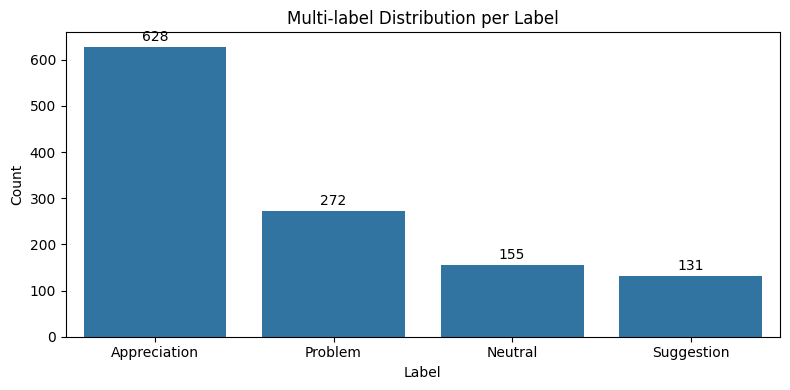

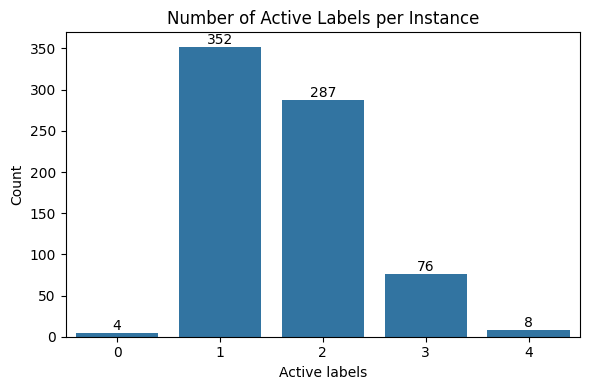

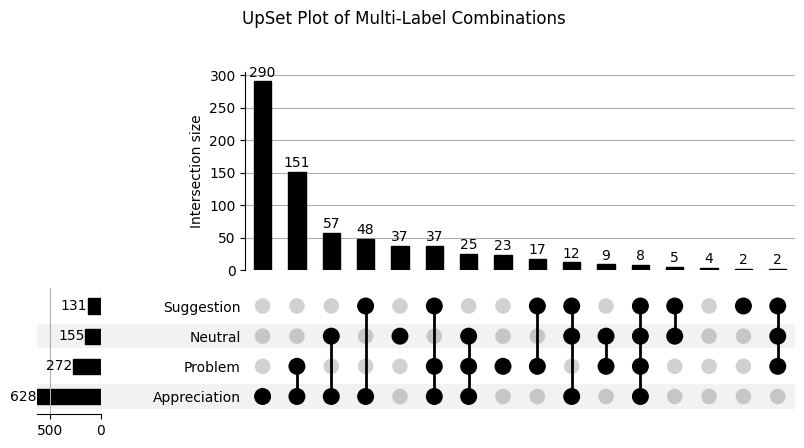

,text,Problem,Suggestion,Appreciation,Neutral,num_active_labels,active_labels,is_multilabel,active_labels_str,text_category,row_id
0,"Menurut saya Baik. karena, di bagian objective...",0,0,1,1,2,"[Appreciation, Neutral]",True,Appreciation|Neutral,Appreciation,0
1,Penjelasan cukup baik tapi materi yang dipapar...,1,0,1,0,2,"[Problem, Appreciation]",True,Problem|Appreciation,Problem,1
2,Penggunaan bahasa dan kalimat dapat dipahami. ...,0,1,1,0,2,"[Suggestion, Appreciation]",True,Suggestion|Appreciation,Suggestion,2
3,Penilaian saya terhadap Kelompok 7 didasari ol...,1,0,1,0,2,"[Problem, Appreciation]",True,Problem|Appreciation,Problem,3
4,Bahasa dan tata cara penulisan yang digunakan ...,1,0,0,0,1,[Problem],False,Problem,Problem,4


(723, 11)
text_category
Appreciation    347
Problem         272
Suggestion       67
Neutral          37
Name: count, dtype: int64
Rows with >1 active labels: 371


In [6]:

raw_multilabel = pd.read_csv(MULTILABEL_DATA_PATH).copy()

required_cols = [TEXT] + MULTILABEL_LABEL_COLS
missing_cols = [col for col in required_cols if col not in raw_multilabel.columns]
if missing_cols:
    raise ValueError(
        f"Multi-label dataset must contain columns {required_cols}. Missing: {missing_cols}. "
        f"Available columns: {raw_multilabel.columns.tolist()}"
    )

raw_multilabel = raw_multilabel[required_cols].copy()
raw_multilabel = raw_multilabel.dropna(subset=[TEXT]).copy()
raw_multilabel[TEXT] = raw_multilabel[TEXT].astype(str).progress_apply(basic_clean)
raw_multilabel[TEXT] = raw_multilabel[TEXT].replace(r'^\s*$', np.nan, regex=True)
raw_multilabel = raw_multilabel.dropna(subset=[TEXT]).reset_index(drop=True)

multilabel_df = coerce_binary_multilabel_columns(raw_multilabel, MULTILABEL_LABEL_COLS)
multilabel_df["num_active_labels"] = multilabel_df[MULTILABEL_LABEL_COLS].sum(axis=1)

label_counts = multilabel_df[MULTILABEL_LABEL_COLS].sum().sort_values(ascending=False)
display(label_counts.rename("count").to_frame())

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)
for i, v in enumerate(label_counts.values):
    ax.text(i, v + max(label_counts.values) * 0.01, str(int(v)), ha="center", va="bottom", fontsize=10)
plt.title("Multi-label Distribution per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=multilabel_df, x="num_active_labels")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.title("Number of Active Labels per Instance")
plt.xlabel("Active labels")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

_ = try_make_upset_plot(multilabel_df, MULTILABEL_LABEL_COLS)

dataset = semantic_priority_transform(
    multilabel_df,
    text_col=TEXT,
    label_cols=MULTILABEL_LABEL_COLS,
    priority_map=PRIORITY_MAP,
    output_label_col=LABEL,
)

dataset = dataset.dropna(subset=[TEXT, LABEL]).copy()
dataset = dataset[dataset[LABEL].astype(str).str.strip() != ""].copy()
dataset = dataset.reset_index(drop=True)
dataset["row_id"] = np.arange(len(dataset), dtype=int)

dataset.to_csv(os.path.join(OUTPUT_DIR, "single_label_priority_transformed_dataset.csv"), index=False)
(
    dataset["active_labels_str"]
    .value_counts()
    .rename_axis("label_combination")
    .reset_index(name="count")
    .to_csv(os.path.join(OUTPUT_DIR, "multilabel_combination_summary.csv"), index=False)
)

display(dataset.head())
print(dataset.shape)
print(dataset[LABEL].value_counts())
print("Rows with >1 active labels:", int(dataset["is_multilabel"].sum()))


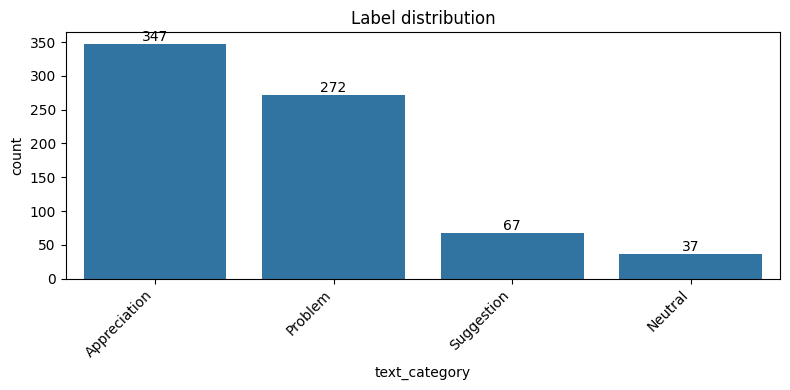

In [7]:

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=dataset, x=LABEL, order=dataset[LABEL].value_counts().index)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=45, ha='right')
plt.title("Label distribution")
plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig(os.path.join(OUTPUT_DIR, "label_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()


## Outer split and model-selection split

In [8]:

split_bundle = load_or_create_shared_splits(
    dataset=dataset,
    label_col=LABEL,
    seed=SEED,
    test_size=OUTER_TEST_SIZE,
    valid_size=SELECTION_VALID_SIZE,
    split_dir=SHARED_SPLIT_DIR,
)

selection_train_df = split_bundle["train_df"].copy()
selection_valid_df = split_bundle["valid_df"].copy()
test_df = split_bundle["test_df"].copy()
train_full_df = pd.concat([selection_train_df, selection_valid_df], ignore_index=True)

print("train_full_df:", train_full_df.shape)
print("selection_train_df:", selection_train_df.shape)
print("selection_valid_df:", selection_valid_df.shape)
print("test_df:", test_df.shape)
print("Shared split file:", split_bundle["split_assignment_path"])


train_full_df: (578, 11)
selection_train_df: (462, 11)
selection_valid_df: (116, 11)
test_df: (145, 11)
Shared split file: /home/jupyter-sigitpurnomo/jupyter-data/ysp-research/pr-icitcom/shared_splits_singleclasses/multilabel_priority_singlelabel_basicclean_v1_seed42_test20_valid20/split_assignments.csv


In [9]:

encoder = LabelEncoder()
encoder.fit(train_full_df[LABEL])

selection_train_y = encoder.transform(selection_train_df[LABEL])
selection_valid_y = encoder.transform(selection_valid_df[LABEL])
train_full_y = encoder.transform(train_full_df[LABEL])
test_y = encoder.transform(test_df[LABEL])

label_order = list(encoder.classes_)
num_classes = len(label_order)

with open(os.path.join(OUTPUT_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(encoder, f)

pd.DataFrame({"label": label_order, "encoded": list(range(len(label_order)))})


,label,encoded
0,Appreciation,0
1,Neutral,1
2,Problem,2
3,Suggestion,3


## Optional stopword cleaning snapshot (for inspection only)

In [10]:
stop_word = None
if os.path.exists(STOPWORD_PATH):
    def load_stopwords(path):
        with open(path, "r", encoding="utf-8") as f:
            words = [line.strip() for line in f if line.strip()]
        return np.array(words, dtype=str)

    stop_word = load_stopwords(STOPWORD_PATH)


def remove_stop_words(text, stop_word_list):
    if stop_word_list is None:
        return text
    tokens = text_to_word_sequence(str(text))
    filtered = [tok for tok in tokens if tok not in stop_word_list]
    return " ".join(filtered)

for df_ in [train_full_df, test_df, selection_train_df, selection_valid_df]:
    df_[TEXT + "_sw"] = df_[TEXT].progress_apply(lambda x: remove_stop_words(x, stop_word))

train_full_df[[TEXT, TEXT + "_sw", LABEL]].head()


  0%|          | 0/578 [00:00<?, ?it/s]

  0%|          | 0/145 [00:00<?, ?it/s]

  0%|          | 0/462 [00:00<?, ?it/s]

  0%|          | 0/116 [00:00<?, ?it/s]

,text,text_sw,text_category
0,"Menurut saya Baik. karena, di bagian objective...",menurut baik bagian objective jelaskan berbaga...,Appreciation
1,Penggunaan bahasa dan kalimat dapat dipahami. ...,penggunaan bahasa kalimat dipahami pemaparan i...,Suggestion
2,Penilaian saya terhadap Kelompok 7 didasari ol...,penilaian kelompok 7 didasari cara mendefinisi...,Problem
3,Bahasa dan tata cara penulisan yang digunakan ...,bahasa tata cara penulisan digunakan baku dipe...,Problem
4,Bagian analisis tentang pemilihan studi kasus ...,bagian analisis pemilihan studi kasus aspek as...,Suggestion


## fastText loader and tokenization helpers

In [11]:

if USE_PRETRAINED and (not FASTTEXT_IMPORT_OK or not os.path.exists(FASTTEXT_PATH)):
    print("Pre-trained embeddings unavailable. Falling back to randomly initialized embeddings.")
    USE_PRETRAINED = False

pretrained_model = None
if USE_PRETRAINED:
    pretrained_model = fasttext.load_model(FASTTEXT_PATH)
    print("Loaded fastText model from:", FASTTEXT_PATH)


Loaded fastText model from: /home/jupyter-sigitpurnomo/research/peer-code-review/cc.id.300.bin


In [12]:

def fit_tokenizer(texts, num_words=None):
    tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(list(texts))
    return tokenizer


def texts_to_padded(tokenizer, texts, max_len):
    seqs = tokenizer.texts_to_sequences(list(texts))
    return sequence.pad_sequences(seqs, maxlen=max_len)


def build_embedding_matrix(tokenizer, embedding_dim=300, ft_model=None):
    vocab_size = len(tokenizer.word_index) + 1
    matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
    if ft_model is None:
        return matrix
    for word, idx in tokenizer.word_index.items():
        matrix[idx] = ft_model.get_word_vector(word)
    return matrix


def prepare_text_representation(train_texts, other_texts_list, max_len=300, num_words=None, use_pretrained=False, ft_model=None):
    tokenizer = fit_tokenizer(train_texts, num_words=num_words)
    train_seq = texts_to_padded(tokenizer, train_texts, max_len)
    other_seqs = [texts_to_padded(tokenizer, texts, max_len) for texts in other_texts_list]
    embedding_matrix = None
    embedding_dim = 100
    if use_pretrained:
        embedding_dim = 300
        embedding_matrix = build_embedding_matrix(tokenizer, embedding_dim=embedding_dim, ft_model=ft_model)
    vocab_size = len(tokenizer.word_index) + 1
    return tokenizer, train_seq, other_seqs, vocab_size, embedding_matrix, embedding_dim


## Model builders

In [13]:

def make_embedding_layer(vocab_size, embedding_dim, embedding_matrix=None, use_pretrained=False):
    if use_pretrained and embedding_matrix is not None:
        return layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False,
        )
    return layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)


def output_layer(num_classes):
    if num_classes <= 2:
        return layers.Dense(1, activation="sigmoid")
    return layers.Dense(num_classes, activation="softmax")


def compile_model(model, num_classes):
    if num_classes <= 2:
        model.compile(
            optimizer="adam",
            loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
            metrics=["accuracy"],
        )
    else:
        model.compile(
            optimizer="adam",
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"],
        )
    return model


def shallow_neural_network(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.GlobalAveragePooling1D(),
        output_layer(num_classes),
    ])
    return model


def deep_neural_network(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation="relu"),
        output_layer(num_classes),
    ])
    return model


def deep_neural_network_var1(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        output_layer(num_classes),
    ])
    return model


def deep_neural_network_var2(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        output_layer(num_classes),
    ])
    return model


def create_rnn_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.SimpleRNN(32, return_sequences=True, activation="tanh"),
        layers.SimpleRNN(32, return_sequences=True, activation="tanh"),
        layers.SimpleRNN(32, return_sequences=True, activation="tanh"),
        layers.SimpleRNN(32, activation="tanh"),
        output_layer(num_classes),
    ])
    return model


def create_conv_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.Conv1D(128, 5, activation="relu"),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.5),
        layers.Conv1D(64, 5, activation="relu"),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        layers.Conv1D(32, 5, activation="relu"),
        layers.GlobalMaxPooling1D(),
        output_layer(num_classes),
    ])
    return model


def create_lstm_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.LSTM(32, activation="tanh"),
        output_layer(num_classes),
    ])
    return model


def create_cnn_lstm_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.Conv1D(128, 5, activation="relu"),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        layers.LSTM(32, activation="tanh"),
        output_layer(num_classes),
    ])
    return model


def create_cnn_gru_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.Conv1D(128, 5, activation="relu"),
        layers.MaxPooling1D(pool_size=4),
        layers.Dropout(0.2),
        layers.GRU(32, activation="tanh"),
        output_layer(num_classes),
    ])
    return model


def create_gru_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.GRU(32, activation="tanh"),
        output_layer(num_classes),
    ])
    return model


def create_bidirec_rnn_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.Bidirectional(layers.SimpleRNN(32, return_sequences=True, activation="tanh")),
        layers.Bidirectional(layers.SimpleRNN(32, return_sequences=True, activation="tanh")),
        layers.Bidirectional(layers.SimpleRNN(32, return_sequences=True, activation="tanh")),
        layers.Bidirectional(layers.SimpleRNN(32, activation="tanh")),
        output_layer(num_classes),
    ])
    return model


def create_bidirec_lstm_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.Bidirectional(layers.LSTM(32, activation="tanh")),
        output_layer(num_classes),
    ])
    return model


def create_bidirec_gru_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.Bidirectional(layers.GRU(32, activation="tanh")),
        output_layer(num_classes),
    ])
    return model


def create_rcnn_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.SpatialDropout1D(0.3),
        layers.Bidirectional(layers.GRU(32, return_sequences=True, activation="tanh")),
        layers.Convolution1D(32, 3, activation="tanh"),
        layers.GlobalMaxPool1D(),
        layers.Dense(25, activation="relu"),
        output_layer(num_classes),
    ])
    return model


def create_rcnn_var1_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.SpatialDropout1D(0.3),
        layers.Bidirectional(layers.LSTM(32, return_sequences=True, activation="tanh")),
        layers.Convolution1D(32, 3, activation="relu"),
        layers.GlobalMaxPool1D(),
        layers.Dense(25, activation="relu"),
        output_layer(num_classes),
    ])
    return model


def create_rcnn_var2_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.SpatialDropout1D(0.3),
        layers.Bidirectional(layers.GRU(32, return_sequences=True, activation="tanh")),
        layers.Bidirectional(layers.GRU(32, return_sequences=True, activation="tanh")),
        layers.Convolution1D(32, 3, activation="relu"),
        layers.GlobalMaxPool1D(),
        layers.Dense(25, activation="relu"),
        output_layer(num_classes),
    ])
    return model


def create_rcnn_var3_model(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embedded = make_embedding_layer(vocab_size, embedding_dim, embedding_matrix, use_pretrained)
    model = keras.Sequential([
        embedded,
        layers.SpatialDropout1D(0.3),
        layers.Bidirectional(layers.GRU(32, return_sequences=True, activation="tanh")),
        layers.Bidirectional(layers.LSTM(32, return_sequences=True, activation="tanh")),
        layers.Convolution1D(32, 3, activation="relu"),
        layers.GlobalMaxPool1D(),
        layers.Dense(25, activation="relu"),
        output_layer(num_classes),
    ])
    return model


In [14]:

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads")
        self.projection_dim = embed_dim // num_heads
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        attention = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        return self.combine_heads(concat_attention)

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = int(embed_dim)
        self.num_heads = int(num_heads)
        self.ff_dim = int(ff_dim)
        self.rate = float(rate)
        self.att = MultiHeadSelfAttention(self.embed_dim, self.num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(self.ff_dim, activation="relu"),
            layers.Dense(self.embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(self.rate)
        self.dropout2 = layers.Dropout(self.rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config


class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({"maxlen": self.maxlen, "vocab_size": self.vocab_size, "embed_dim": self.embed_dim})
        return config


def transformers_classifier(vocab_size, num_classes, embedding_dim, embedding_matrix=None, use_pretrained=False, max_len=300):
    embed_dim = 32
    num_heads = 2
    ff_dim = 32
    inputs = layers.Input(shape=(max_len,))
    x = TokenAndPositionEmbedding(max_len, vocab_size, embed_dim)(inputs)
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = output_layer(num_classes)(x)
    return keras.Model(inputs=inputs, outputs=outputs)


In [15]:

MODEL_REGISTRY = {
    "Shallow_NN_WE": shallow_neural_network,
    "Deep_NN_WE": deep_neural_network,
    "Deep_NN_var1_WE": deep_neural_network_var1,
    "Deep_NN_var2_WE": deep_neural_network_var2,
    "RNN_WE": create_rnn_model,
    "CNN_WE": create_conv_model,
    "LSTM_WE": create_lstm_model,
    "CNN_LSTM_WE": create_cnn_lstm_model,
    "CNN_GRU_WE": create_cnn_gru_model,
    "GRU_WE": create_gru_model,
    "BiRNN_WE": create_bidirec_rnn_model,
    "BiLSTM_WE": create_bidirec_lstm_model,
    "BiGRU_WE": create_bidirec_gru_model,
    "RCNN_WE": create_rcnn_model,
    "RCNN_var1_WE": create_rcnn_var1_model,
    "RCNN_var2_WE": create_rcnn_var2_model,
    "RCNN_var3_WE": create_rcnn_var3_model,
    "Transformers_WE": transformers_classifier,
}

active_models = [name for name, flag in MODEL_FLAGS.items() if flag]
print(active_models)


['RNN_WE', 'CNN_WE', 'LSTM_WE', 'CNN_LSTM_WE', 'CNN_GRU_WE', 'GRU_WE', 'BiRNN_WE', 'BiLSTM_WE', 'BiGRU_WE', 'RCNN_WE', 'RCNN_var1_WE', 'RCNN_var2_WE', 'RCNN_var3_WE', 'Transformers_WE']


## Evaluation helpers

In [16]:

def predict_classes(model, X, num_classes):
    y_score = model.predict(X, verbose=0)
    if num_classes <= 2:
        y_pred = (y_score.ravel() >= 0.5).astype(int)
        confidence = y_score.ravel()
    else:
        y_pred = np.argmax(y_score, axis=1)
        confidence = np.max(y_score, axis=1)
    return y_pred, y_score, confidence


def compute_metric_dict(y_true, y_pred):
    average = "binary" if len(np.unique(y_true)) <= 2 else "weighted"
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average=average, zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "matthews_corrcoef": matthews_corrcoef(y_true, y_pred),
    }


def make_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(cls): float(w) for cls, w in zip(classes, weights)}


def cleanup_tf():
    K.clear_session()
    gc.collect()


def is_dnn_stream_executor_error(exc):
    msg = str(exc)
    patterns = [
        "No DNN in stream executor",
        "DNN library is not found",
        "Failed to get convolution algorithm",
        "could not create cudnn handle",
    ]
    return any(pat in msg for pat in patterns)


def get_device_context(force_cpu=False):
    return tf.device("/CPU:0") if force_cpu else contextlib.nullcontext()


def build_compiled_model(builder_fn, vocab_size, num_classes, embedding_dim, embedding_matrix, use_pretrained, max_len, force_cpu=False):
    with get_device_context(force_cpu):
        model = builder_fn(
            vocab_size=vocab_size,
            num_classes=num_classes,
            embedding_dim=embedding_dim,
            embedding_matrix=embedding_matrix,
            use_pretrained=use_pretrained,
            max_len=max_len,
        )
        model = compile_model(model, num_classes)
    return model


In [17]:

def fit_single_model(builder_fn, train_texts, train_labels, valid_texts, valid_labels,
                     num_classes, max_len, num_words, use_pretrained, ft_model,
                     batch_size, epochs, patience, use_class_weights, seed):
    def run_once(force_cpu=False):
        random.seed(seed)
        np.random.seed(seed)
        tf.keras.utils.set_random_seed(seed)
        cleanup_tf()

        tokenizer, X_train, [X_valid], vocab_size, embedding_matrix, embedding_dim = prepare_text_representation(
            train_texts,
            [valid_texts],
            max_len=max_len,
            num_words=num_words,
            use_pretrained=use_pretrained,
            ft_model=ft_model,
        )

        model = build_compiled_model(
            builder_fn=builder_fn,
            vocab_size=vocab_size,
            num_classes=num_classes,
            embedding_dim=embedding_dim,
            embedding_matrix=embedding_matrix,
            use_pretrained=use_pretrained,
            max_len=max_len,
            force_cpu=force_cpu,
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=patience,
                restore_best_weights=True,
                verbose=0,
            )
        ]

        class_weight = make_class_weights(train_labels) if use_class_weights else None

        fit_start = time.time()
        with get_device_context(force_cpu):
            history = model.fit(
                X_train,
                train_labels,
                validation_data=(X_valid, valid_labels),
                epochs=epochs,
                batch_size=batch_size,
                verbose=0,
                shuffle=True,
                callbacks=callbacks,
                class_weight=class_weight,
            )
        fit_time = time.time() - fit_start

        score_start = time.time()
        with get_device_context(force_cpu):
            y_pred, y_score, confidence = predict_classes(model, X_valid, num_classes)
        score_time = time.time() - score_start
        metrics_dict = compute_metric_dict(valid_labels, y_pred)

        if "val_loss" in history.history and len(history.history["val_loss"]) > 0:
            best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        else:
            best_epoch = int(len(history.history.get("loss", [])) or epochs)

        return {
            "model": model,
            "tokenizer": tokenizer,
            "history": history.history,
            "best_epoch": best_epoch,
            "epochs_ran": int(len(history.history.get("loss", []))),
            "X_valid": X_valid,
            "y_valid_pred": y_pred,
            "y_valid_score": y_score,
            "confidence": confidence,
            "fit_time": fit_time,
            "score_time": score_time,
            "metrics": metrics_dict,
            "vocab_size": vocab_size,
            "forced_cpu": bool(force_cpu),
        }

    try:
        return run_once(force_cpu=False)
    except tf.errors.InvalidArgumentError as e:
        if not is_dnn_stream_executor_error(e):
            raise
        print(f"GPU DNN backend unavailable for {builder_fn.__name__}; retrying on CPU.")
        return run_once(force_cpu=True)


In [18]:

def evaluate_model_for_selection(model_name, builder_fn,
                                 selection_train_texts, selection_train_y,
                                 selection_valid_texts, selection_valid_y,
                                 num_classes, max_len, num_words,
                                 use_pretrained, ft_model,
                                 batch_size, epochs, patience,
                                 use_class_weights, seed):
    skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=seed)
    cv_rows = []

    selection_train_texts = np.array(selection_train_texts)
    selection_train_y = np.array(selection_train_y)

    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(selection_train_texts, selection_train_y), start=1):
        fold_result = fit_single_model(
            builder_fn=builder_fn,
            train_texts=selection_train_texts[tr_idx],
            train_labels=selection_train_y[tr_idx],
            valid_texts=selection_train_texts[va_idx],
            valid_labels=selection_train_y[va_idx],
            num_classes=num_classes,
            max_len=max_len,
            num_words=num_words,
            use_pretrained=use_pretrained,
            ft_model=ft_model,
            batch_size=batch_size,
            epochs=epochs,
            patience=patience,
            use_class_weights=use_class_weights,
            seed=seed + fold_idx,
        )
        row = {
            "Model": model_name,
            "fold": fold_idx,
            "fit_time": fold_result["fit_time"],
            "score_time": fold_result["score_time"],
            "best_epoch": fold_result["best_epoch"],
            "epochs_ran": fold_result["epochs_ran"],
        }
        row.update(fold_result["metrics"])
        cv_rows.append(row)
        cleanup_tf()

    cv_df = pd.DataFrame(cv_rows)

    valid_result = fit_single_model(
        builder_fn=builder_fn,
        train_texts=selection_train_texts,
        train_labels=selection_train_y,
        valid_texts=np.array(selection_valid_texts),
        valid_labels=np.array(selection_valid_y),
        num_classes=num_classes,
        max_len=max_len,
        num_words=num_words,
        use_pretrained=use_pretrained,
        ft_model=ft_model,
        batch_size=batch_size,
        epochs=epochs,
        patience=patience,
        use_class_weights=use_class_weights,
        seed=seed + 1000,
    )

    summary = {
        "Model": model_name,
        "Representation": "Word Embeddings",
        "Text_Column": TEXT,
        "Use_Pretrained": use_pretrained,
        "cv_fit_time_mean": cv_df["fit_time"].mean(),
        "cv_fit_time_std": cv_df["fit_time"].std(ddof=0),
        "cv_score_time_mean": cv_df["score_time"].mean(),
        "cv_score_time_std": cv_df["score_time"].std(ddof=0),
        "cv_best_epoch_mean": cv_df["best_epoch"].mean(),
        "cv_best_epoch_median": cv_df["best_epoch"].median(),
        "cv_epochs_ran_mean": cv_df["epochs_ran"].mean(),
        "cv_test_accuracy_mean": cv_df["accuracy"].mean(),
        "cv_test_accuracy_std": cv_df["accuracy"].std(ddof=0),
        "cv_test_balanced_accuracy_mean": cv_df["balanced_accuracy"].mean(),
        "cv_test_balanced_accuracy_std": cv_df["balanced_accuracy"].std(ddof=0),
        "cv_test_precision_weighted_mean": cv_df["precision_weighted"].mean(),
        "cv_test_precision_weighted_std": cv_df["precision_weighted"].std(ddof=0),
        "cv_test_recall_weighted_mean": cv_df["recall_weighted"].mean(),
        "cv_test_recall_weighted_std": cv_df["recall_weighted"].std(ddof=0),
        "cv_test_f1_weighted_mean": cv_df["f1_weighted"].mean(),
        "cv_test_f1_weighted_std": cv_df["f1_weighted"].std(ddof=0),
        "cv_test_cohen_kappa_mean": cv_df["cohen_kappa"].mean(),
        "cv_test_cohen_kappa_std": cv_df["cohen_kappa"].std(ddof=0),
        "cv_test_matthews_corrcoef_mean": cv_df["matthews_corrcoef"].mean(),
        "cv_test_matthews_corrcoef_std": cv_df["matthews_corrcoef"].std(ddof=0),
        "valid_fit_time": valid_result["fit_time"],
        "valid_score_time": valid_result["score_time"],
        "valid_best_epoch": valid_result["best_epoch"],
        "valid_epochs_ran": valid_result["epochs_ran"],
        "valid_accuracy": valid_result["metrics"]["accuracy"],
        "valid_balanced_accuracy": valid_result["metrics"]["balanced_accuracy"],
        "valid_precision_weighted": valid_result["metrics"]["precision_weighted"],
        "valid_recall_weighted": valid_result["metrics"]["recall_weighted"],
        "valid_f1_weighted": valid_result["metrics"]["f1_weighted"],
        "valid_cohen_kappa": valid_result["metrics"]["cohen_kappa"],
        "valid_matthews_corrcoef": valid_result["metrics"]["matthews_corrcoef"],
        "vocab_size": valid_result["vocab_size"],
        "valid_forced_cpu": valid_result["forced_cpu"],
    }

    valid_predictions = pd.DataFrame({
        "Model": model_name,
        "row_index": np.arange(len(selection_valid_texts)),
        "text": selection_valid_texts,
        "y_true": encoder.inverse_transform(selection_valid_y),
        "y_pred": encoder.inverse_transform(valid_result["y_valid_pred"]),
        "confidence": valid_result["confidence"],
    })

    cleanup_tf()
    return summary, cv_df, valid_predictions


## Run model selection

In [ ]:
leaderboard_rows = []
cv_detail_frames = []
valid_prediction_frames = []

for model_name in active_models:
    print("=" * 80)
    print("Evaluating:", model_name)
    builder_fn = MODEL_REGISTRY[model_name]
    summary, cv_df, valid_predictions = evaluate_model_for_selection(
        model_name=model_name,
        builder_fn=builder_fn,
        selection_train_texts=selection_train_df[TEXT].values,
        selection_train_y=selection_train_y,
        selection_valid_texts=selection_valid_df[TEXT].values,
        selection_valid_y=selection_valid_y,
        num_classes=num_classes,
        max_len=MAX_LEN,
        num_words=NUM_WORDS,
        use_pretrained=USE_PRETRAINED,
        ft_model=pretrained_model,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        patience=PATIENCE,
        use_class_weights=USE_CLASS_WEIGHTS,
        seed=SEED,
    )
    leaderboard_rows.append(summary)
    cv_detail_frames.append(cv_df)
    valid_prediction_frames.append(valid_predictions)

leaderboard = pd.DataFrame(leaderboard_rows)
cv_details = pd.concat(cv_detail_frames, ignore_index=True) if cv_detail_frames else pd.DataFrame()
valid_predictions_all = pd.concat(valid_prediction_frames, ignore_index=True) if valid_prediction_frames else pd.DataFrame()


def apply_model_selection_strategy(
    leaderboard_df,
    cv_mean_col="cv_test_f1_weighted_mean",
    cv_std_col="cv_test_f1_weighted_std",
    valid_col="valid_f1_weighted",
    shortlist_top_k=5,
    cv_tolerance=0.005,
):
    df = leaderboard_df.copy()

    required_cols = [cv_mean_col, cv_std_col, valid_col]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required selection columns: {missing_cols}")

    for col in required_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=required_cols).copy()

    cv_ranked = df.sort_values(
        by=[cv_mean_col, cv_std_col],
        ascending=[False, True],
    ).reset_index(drop=True)
    cv_ranked["cv_rank"] = np.arange(1, len(cv_ranked) + 1)

    best_cv = cv_ranked.iloc[0][cv_mean_col]
    top_k_candidates = cv_ranked.head(shortlist_top_k).copy()
    near_best_candidates = cv_ranked[cv_ranked[cv_mean_col] >= (best_cv - cv_tolerance)].copy()

    shortlist = (
        pd.concat([top_k_candidates, near_best_candidates], axis=0)
        .drop_duplicates(subset=["Model"])
        .copy()
    )

    shortlist = shortlist.sort_values(
        by=[valid_col, cv_mean_col, cv_std_col],
        ascending=[False, False, True],
    ).reset_index(drop=True)
    shortlist["selection_rank"] = np.arange(1, len(shortlist) + 1)

    selection_rank_map = shortlist[["Model", "selection_rank"]].copy()

    enriched = cv_ranked.merge(selection_rank_map, on="Model", how="left")
    enriched = enriched.sort_values(
        by=["selection_rank", "cv_rank"],
        ascending=[True, True],
        na_position="last",
    ).reset_index(drop=True)

    best_row = shortlist.iloc[0].copy()
    return enriched, shortlist, best_row


leaderboard, selection_shortlist, best_row = apply_model_selection_strategy(
    leaderboard_df=leaderboard,
    cv_mean_col="cv_test_f1_weighted_mean",
    cv_std_col="cv_test_f1_weighted_std",
    valid_col="valid_f1_weighted",
    shortlist_top_k=5,
    cv_tolerance=0.005,
)

leaderboard.to_csv(os.path.join(OUTPUT_DIR, "leaderboard_model_selection.csv"), index=False)
cv_details.to_csv(os.path.join(OUTPUT_DIR, "cv_fold_metrics.csv"), index=False)
valid_predictions_all.to_csv(os.path.join(OUTPUT_DIR, "selection_valid_predictions_all.csv"), index=False)
selection_shortlist.to_csv(os.path.join(OUTPUT_DIR, "selection_shortlist.csv"), index=False)
selection_shortlist.to_csv(os.path.join(OUTPUT_DIR, "selection_shortlist_model_selection.csv"), index=False)

leaderboard_display_columns = [
    "Model",
    "cv_rank",
    "selection_rank",
    "cv_test_f1_weighted_mean",
    "cv_test_f1_weighted_std",
    "valid_f1_weighted",
    "cv_test_balanced_accuracy_mean",
    "valid_balanced_accuracy",
    "valid_matthews_corrcoef",
]

display(leaderboard.loc[:, leaderboard_display_columns].head(10))


Evaluating: RNN_WE


E0000 00:00:1782474583.807784 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1782474646.791834 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

E0000 00:00:1782475731.363752 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1782476200.749649 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

Evaluating: CNN_WE


E0000 00:00:1782477043.636388 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1782477048.780341 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

...

E0000 00:00:1782477520.712238 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1782477538.144222 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

Evaluating: GRU_WE


E0000 00:00:1782477663.307186 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1782477690.088005 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

Evaluating: BiRNN_WE


E0000 00:00:1782477992.668066 2401775 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


## Top 5 models for paper reporting

For the paper, use these three metrics because they are the most informative for imbalanced multi-class classification:

- **Weighted F1**: the main summary metric for overall classification quality.
- **Balanced Accuracy**: more robust than plain accuracy when class frequencies are uneven.
- **Matthews Correlation Coefficient (MCC)**: a strong single-number summary of prediction quality.

The **ranking** still follows the full model-selection rule, but the table below shows only the three paper-friendly metrics on the held-out validation split.


In [ ]:
selection_top5_display_columns = [
    "selection_rank",
    "cv_rank",
    "Model",
    "cv_test_f1_weighted_mean",
    "cv_test_f1_weighted_std",
    "valid_f1_weighted",
    "cv_test_balanced_accuracy_mean",
    "valid_balanced_accuracy",
    "valid_matthews_corrcoef",
]

selection_top5_models = (
    selection_shortlist
    .sort_values(by=["selection_rank", "cv_rank"], ascending=[True, True])
    .loc[:, selection_top5_display_columns]
    .head(5)
    .reset_index(drop=True)
)

selection_top5_models = selection_top5_models.rename(columns={
    "selection_rank": "Selection_Rank",
    "cv_rank": "CV_Rank",
})

display(
    selection_top5_models.style.format({
        "cv_test_f1_weighted_mean": "{:.4f}",
        "cv_test_f1_weighted_std": "{:.4f}",
        "valid_f1_weighted": "{:.4f}",
        "cv_test_balanced_accuracy_mean": "{:.4f}",
        "valid_balanced_accuracy": "{:.4f}",
        "valid_matthews_corrcoef": "{:.4f}",
    })
)

selection_top5_models.to_csv(
    os.path.join(OUTPUT_DIR, "top5_models_selection_stage.csv"),
    index=False
)

selection_top5_models.to_csv(
    os.path.join(OUTPUT_DIR, "top5_models_for_paper.csv"),
    index=False
)


In [ ]:
selection_strategy = {
    "shortlist_basis": "highest cv_test_f1_weighted_mean",
    "shortlist_tie_breaker": "lowest cv_test_f1_weighted_std",
    "shortlist_top_k": 5,
    "shortlist_cv_tolerance": 0.005,
    "final_selection_basis": "highest valid_f1_weighted within shortlisted models",
    "final_tie_breaker_1": "highest cv_test_f1_weighted_mean",
    "final_tie_breaker_2": "lowest cv_test_f1_weighted_std",
}

best_row_df = best_row.to_frame().T
best_row_df.to_csv(os.path.join(OUTPUT_DIR, "best_model_summary.csv"), index=False)
best_row_df


## Refit best model on full outer train and evaluate on outer test

In [ ]:

def fit_best_model_on_outer_train(builder_fn, train_texts, train_labels,
                                  test_texts, test_labels,
                                  num_classes, max_len, num_words,
                                  use_pretrained, ft_model,
                                  batch_size, final_epochs,
                                  use_class_weights, seed):
    def run_once(force_cpu=False):
        random.seed(seed)
        np.random.seed(seed)
        tf.keras.utils.set_random_seed(seed)
        cleanup_tf()

        tokenizer, X_train_full, [X_test], vocab_size, embedding_matrix, embedding_dim = prepare_text_representation(
            train_texts,
            [test_texts],
            max_len=max_len,
            num_words=num_words,
            use_pretrained=use_pretrained,
            ft_model=ft_model,
        )

        model = build_compiled_model(
            builder_fn=builder_fn,
            vocab_size=vocab_size,
            num_classes=num_classes,
            embedding_dim=embedding_dim,
            embedding_matrix=embedding_matrix,
            use_pretrained=use_pretrained,
            max_len=max_len,
            force_cpu=force_cpu,
        )

        class_weight = make_class_weights(train_labels) if use_class_weights else None

        fit_start = time.time()
        with get_device_context(force_cpu):
            history = model.fit(
                X_train_full,
                train_labels,
                epochs=final_epochs,
                batch_size=batch_size,
                verbose=0,
                shuffle=True,
                class_weight=class_weight,
            )
        fit_time = time.time() - fit_start

        score_start = time.time()
        with get_device_context(force_cpu):
            y_pred, y_score, confidence = predict_classes(model, X_test, num_classes)
        score_time = time.time() - score_start
        metrics_dict = compute_metric_dict(test_labels, y_pred)

        return {
            "model": model,
            "tokenizer": tokenizer,
            "history": history.history,
            "final_epochs": int(final_epochs),
            "X_test": X_test,
            "y_pred": y_pred,
            "y_score": y_score,
            "confidence": confidence,
            "metrics": metrics_dict,
            "fit_time": fit_time,
            "score_time": score_time,
            "vocab_size": vocab_size,
            "forced_cpu": bool(force_cpu),
        }

    try:
        return run_once(force_cpu=False)
    except tf.errors.InvalidArgumentError as e:
        if not is_dnn_stream_executor_error(e):
            raise
        print(f"GPU DNN backend unavailable for {builder_fn.__name__} during final refit; retrying on CPU.")
        return run_once(force_cpu=True)


In [ ]:

best_model_name = best_row["Model"]
best_builder_fn = MODEL_REGISTRY[best_model_name]

final_epochs = int(max(1, round(best_row.get("valid_best_epoch", best_row.get("cv_best_epoch_median", EPOCHS)))))

final_result = fit_best_model_on_outer_train(
    builder_fn=best_builder_fn,
    train_texts=train_full_df[TEXT].values,
    train_labels=train_full_y,
    test_texts=test_df[TEXT].values,
    test_labels=test_y,
    num_classes=num_classes,
    max_len=MAX_LEN,
    num_words=NUM_WORDS,
    use_pretrained=USE_PRETRAINED,
    ft_model=pretrained_model,
    batch_size=BATCH_SIZE,
    final_epochs=final_epochs,
    use_class_weights=USE_CLASS_WEIGHTS,
    seed=SEED + 5000,
)

final_metrics = pd.DataFrame([{
    "Model": best_model_name,
    "test_fit_time": final_result["fit_time"],
    "test_score_time": final_result["score_time"],
    "final_epochs": final_result["final_epochs"],
    **{f"test_{k}": v for k, v in final_result["metrics"].items()},
    "vocab_size": final_result["vocab_size"],
    "forced_cpu": final_result["forced_cpu"],
}])
final_metrics.to_csv(os.path.join(OUTPUT_DIR, "final_test_metrics.csv"), index=False)
final_metrics


## Final test metrics for the paper

For the final results section of the paper, report the same three metrics on the **held-out test set** for the selected best model.


In [ ]:

final_test_metrics_for_paper = pd.DataFrame([{
    "Model": best_model_name,
    "test_f1_weighted": final_metrics.loc[0, "test_f1_weighted"],
    "test_balanced_accuracy": final_metrics.loc[0, "test_balanced_accuracy"],
    "test_matthews_corrcoef": final_metrics.loc[0, "test_matthews_corrcoef"],
}])

display(
    final_test_metrics_for_paper.style.format({
        "test_f1_weighted": "{:.4f}",
        "test_balanced_accuracy": "{:.4f}",
        "test_matthews_corrcoef": "{:.4f}",
    })
)

final_test_metrics_for_paper.to_csv(
    os.path.join(OUTPUT_DIR, "final_test_metrics_for_paper.csv"),
    index=False
)


## Priority-order ablation experiment for reviewer response

This section directly tests whether the proposed semantic priority order is empirically defensible. The ablation keeps the same cleaned dataset, shared train/validation/test split, selected best architecture, and final evaluation protocol, then compares the main order **Problem > Suggestion > Appreciation > Neutral** against alternative priority orderings. This allows the paper to report whether the central priority assumption changes held-out performance and label-assignment behavior.

In [ ]:

# =============================
# Priority-order ablation experiment
# =============================
# Reviewer motivation:
# The paper claims that Problem > Suggestion > Appreciation > Neutral is a methodological
# contribution. This ablation compares that order with alternative priority orderings
# while controlling the model architecture, split, and evaluation protocol.


def validate_priority_order(priority_order, label_cols):
    """Validate that an ablation order is a permutation of the multi-label columns."""
    if not isinstance(priority_order, (list, tuple)):
        raise TypeError("priority_order must be a list or tuple of label names.")
    if len(priority_order) != len(label_cols):
        raise ValueError(
            f"Priority order must contain {len(label_cols)} labels, got {len(priority_order)}: {priority_order}"
        )
    if set(priority_order) != set(label_cols):
        raise ValueError(
            "Priority order must be a permutation of MULTILABEL_LABEL_COLS. "
            f"Expected {label_cols}, got {priority_order}"
        )
    if len(set(priority_order)) != len(priority_order):
        raise ValueError(f"Priority order contains duplicate labels: {priority_order}")
    return list(priority_order)


def make_priority_map_from_order(priority_order):
    """Convert a priority order into the same high-score-is-higher-priority map used above."""
    priority_order = validate_priority_order(priority_order, MULTILABEL_LABEL_COLS)
    return {label: len(priority_order) - idx for idx, label in enumerate(priority_order)}


def format_priority_order(priority_order):
    return " > ".join(priority_order)


def transform_dataset_with_priority_order(multilabel_source_df, priority_order, output_label_col=LABEL):
    """Create a single-label dataset from the original multi-label source using one priority order."""
    priority_order = validate_priority_order(priority_order, MULTILABEL_LABEL_COLS)
    priority_map = make_priority_map_from_order(priority_order)

    transformed = semantic_priority_transform(
        multilabel_source_df,
        text_col=TEXT,
        label_cols=MULTILABEL_LABEL_COLS,
        priority_map=priority_map,
        output_label_col=output_label_col,
    )
    transformed = transformed.dropna(subset=[TEXT, output_label_col]).copy()
    transformed = transformed[transformed[output_label_col].astype(str).str.strip() != ""].copy()
    transformed = transformed.reset_index(drop=True)

    # row_id must be stable across priority orders because only the selected target label changes;
    # the underlying cleaned texts and active-label sets remain the same.
    transformed["row_id"] = np.arange(len(transformed), dtype=int)
    transformed["priority_order_name"] = None
    return transformed


def apply_existing_split_assignments(dataset_for_order, split_assignment_path):
    """Apply the original shared split to a dataset generated under another priority order."""
    split_df = pd.read_csv(split_assignment_path)
    required_cols = {"row_id", "split"}
    if not required_cols.issubset(split_df.columns):
        raise ValueError(f"Split assignment file must contain {required_cols}.")

    expected = set(dataset_for_order["row_id"].tolist())
    found = set(split_df["row_id"].tolist())
    if expected != found:
        missing_in_split = sorted(expected - found)[:10]
        missing_in_data = sorted(found - expected)[:10]
        raise ValueError(
            "The split assignment does not match the priority-transformed dataset. "
            f"Missing in split sample: {missing_in_split}; missing in data sample: {missing_in_data}"
        )

    split_df = split_df[["row_id", "split"]].copy()
    split_df["split"] = pd.Categorical(split_df["split"], categories=["train", "valid", "test"], ordered=True)
    merged = dataset_for_order.merge(split_df, on="row_id", how="inner")

    train_df = merged[merged["split"] == "train"].copy().drop(columns=["split"]).reset_index(drop=True)
    valid_df = merged[merged["split"] == "valid"].copy().drop(columns=["split"]).reset_index(drop=True)
    test_df_local = merged[merged["split"] == "test"].copy().drop(columns=["split"]).reset_index(drop=True)
    train_full_df_local = pd.concat([train_df, valid_df], ignore_index=True)
    return train_df, valid_df, train_full_df_local, test_df_local


def summarize_assignment_changes(primary_dataset, candidate_dataset, candidate_name):
    """Count how many single-label targets change under an alternative priority order."""
    primary_targets = primary_dataset[["row_id", LABEL]].rename(columns={LABEL: "primary_label"})
    candidate_targets = candidate_dataset[["row_id", LABEL, "active_labels_str", "is_multilabel"]].rename(
        columns={LABEL: "candidate_label"}
    )
    merged = candidate_targets.merge(primary_targets, on="row_id", how="inner")
    merged["priority_order_name"] = candidate_name
    merged["label_changed_vs_primary"] = merged["candidate_label"] != merged["primary_label"]

    return {
        "changed_instances": int(merged["label_changed_vs_primary"].sum()),
        "changed_multilabel_instances": int(
            merged.loc[merged["is_multilabel"], "label_changed_vs_primary"].sum()
        ),
        "total_instances": int(len(merged)),
        "total_multilabel_instances": int(merged["is_multilabel"].sum()),
    }, merged


def make_distribution_table(dataset_for_order, order_name):
    counts = dataset_for_order[LABEL].value_counts().reindex(MULTILABEL_LABEL_COLS, fill_value=0)
    return pd.DataFrame({
        "priority_order_name": order_name,
        "label": counts.index,
        "count": counts.values,
        "proportion": counts.values / max(1, counts.values.sum()),
    })


def make_confusion_long(y_true_labels, y_pred_labels, order_name):
    labels_for_cm = list(MULTILABEL_LABEL_COLS)
    cm_counts = confusion_matrix(y_true_labels, y_pred_labels, labels=labels_for_cm)
    cm_df = pd.DataFrame(cm_counts, index=labels_for_cm, columns=labels_for_cm)
    return (
        cm_df
        .rename_axis(index="true_label", columns="predicted_label")
        .stack()
        .reset_index(name="count")
        .assign(priority_order_name=order_name)
    )


def run_one_priority_order_ablation(order_name, priority_order, seed_offset=0):
    """Train/evaluate the selected best architecture under one priority order."""
    priority_order = validate_priority_order(priority_order, MULTILABEL_LABEL_COLS)
    ablation_dataset = transform_dataset_with_priority_order(multilabel_df, priority_order, output_label_col=LABEL)
    ablation_dataset["priority_order_name"] = order_name

    _, _, ablation_train_full_df, ablation_test_df = apply_existing_split_assignments(
        ablation_dataset,
        split_bundle["split_assignment_path"],
    )

    # Fit the ablation encoder on the complete label set to keep class indices available
    # even if a rare class is absent in a particular training split.
    ablation_encoder = LabelEncoder()
    ablation_encoder.fit(MULTILABEL_LABEL_COLS)

    ablation_train_full_y = ablation_encoder.transform(ablation_train_full_df[LABEL])
    ablation_test_y = ablation_encoder.transform(ablation_test_df[LABEL])
    ablation_num_classes = len(ablation_encoder.classes_)

    if order_name == "primary_semantic" and not ABLATION_RETRAIN_PRIMARY:
        # Reuse the already trained/evaluated final model because it used the same data,
        # split, architecture, final epochs, and primary semantic order.
        result_metrics = final_result["metrics"]
        y_pred = final_result["y_pred"]
        confidence = final_result["confidence"]
        fit_time = final_result["fit_time"]
        score_time = final_result["score_time"]
        forced_cpu = bool(final_result.get("forced_cpu", False))
        vocab_size = int(final_result.get("vocab_size", 0))
    else:
        ablation_result = fit_best_model_on_outer_train(
            builder_fn=best_builder_fn,
            train_texts=ablation_train_full_df[TEXT].values,
            train_labels=ablation_train_full_y,
            test_texts=ablation_test_df[TEXT].values,
            test_labels=ablation_test_y,
            num_classes=ablation_num_classes,
            max_len=MAX_LEN,
            num_words=NUM_WORDS,
            use_pretrained=USE_PRETRAINED,
            ft_model=pretrained_model,
            batch_size=BATCH_SIZE,
            final_epochs=final_epochs,
            use_class_weights=USE_CLASS_WEIGHTS,
            seed=SEED + 8000 + seed_offset,
        )
        result_metrics = ablation_result["metrics"]
        y_pred = ablation_result["y_pred"]
        confidence = ablation_result["confidence"]
        fit_time = ablation_result["fit_time"]
        score_time = ablation_result["score_time"]
        forced_cpu = bool(ablation_result.get("forced_cpu", False))
        vocab_size = int(ablation_result.get("vocab_size", 0))
        del ablation_result
        cleanup_tf()

    y_true_labels = ablation_encoder.inverse_transform(ablation_test_y)
    y_pred_labels = ablation_encoder.inverse_transform(y_pred)

    change_summary, change_detail = summarize_assignment_changes(dataset, ablation_dataset, order_name)

    row = {
        "priority_order_name": order_name,
        "priority_order": format_priority_order(priority_order),
        "Model": best_model_name,
        "final_epochs": int(final_epochs),
        "n_train_full": int(len(ablation_train_full_df)),
        "n_test": int(len(ablation_test_df)),
        "fit_time": fit_time,
        "score_time": score_time,
        "forced_cpu": forced_cpu,
        "vocab_size": vocab_size,
        "changed_instances_vs_primary": change_summary["changed_instances"],
        "changed_multilabel_instances_vs_primary": change_summary["changed_multilabel_instances"],
        "total_instances": change_summary["total_instances"],
        "total_multilabel_instances": change_summary["total_multilabel_instances"],
    }
    row.update({f"test_{metric_name}": metric_value for metric_name, metric_value in result_metrics.items()})

    predictions = ablation_test_df[["row_id", TEXT, LABEL, "active_labels_str", "is_multilabel"]].copy()
    predictions["priority_order_name"] = order_name
    predictions["y_true"] = y_true_labels
    predictions["y_pred"] = y_pred_labels
    predictions["confidence"] = confidence
    predictions["misclassified"] = predictions["y_true"] != predictions["y_pred"]

    distribution = make_distribution_table(ablation_dataset, order_name)
    confusion_long = make_confusion_long(y_true_labels, y_pred_labels, order_name)

    return row, predictions, distribution, change_detail, confusion_long


if RUN_PRIORITY_ORDER_ABLATION:
    priority_ablation_rows = []
    priority_ablation_predictions = []
    priority_ablation_distributions = []
    priority_ablation_change_details = []
    priority_ablation_confusions = []

    for ablation_idx, (order_name, priority_order) in enumerate(PRIORITY_ABLATION_ORDERS.items()):
        print("=" * 80)
        print(f"Priority-order ablation: {order_name} -> {format_priority_order(priority_order)}")
        row, predictions, distribution, change_detail, confusion_long = run_one_priority_order_ablation(
            order_name=order_name,
            priority_order=priority_order,
            seed_offset=ablation_idx,
        )
        priority_ablation_rows.append(row)
        priority_ablation_predictions.append(predictions)
        priority_ablation_distributions.append(distribution)
        priority_ablation_change_details.append(change_detail)
        priority_ablation_confusions.append(confusion_long)

    priority_order_ablation_results = pd.DataFrame(priority_ablation_rows)

    primary_f1 = float(
        priority_order_ablation_results.loc[
            priority_order_ablation_results["priority_order_name"] == "primary_semantic",
            "test_f1_weighted",
        ].iloc[0]
    )
    primary_bal_acc = float(
        priority_order_ablation_results.loc[
            priority_order_ablation_results["priority_order_name"] == "primary_semantic",
            "test_balanced_accuracy",
        ].iloc[0]
    )
    primary_mcc = float(
        priority_order_ablation_results.loc[
            priority_order_ablation_results["priority_order_name"] == "primary_semantic",
            "test_matthews_corrcoef",
        ].iloc[0]
    )

    priority_order_ablation_results["delta_test_f1_weighted_vs_primary"] = (
        priority_order_ablation_results["test_f1_weighted"] - primary_f1
    )
    priority_order_ablation_results["delta_test_balanced_accuracy_vs_primary"] = (
        priority_order_ablation_results["test_balanced_accuracy"] - primary_bal_acc
    )
    priority_order_ablation_results["delta_test_matthews_corrcoef_vs_primary"] = (
        priority_order_ablation_results["test_matthews_corrcoef"] - primary_mcc
    )

    priority_order_ablation_predictions = pd.concat(priority_ablation_predictions, ignore_index=True)
    priority_order_ablation_label_distribution = pd.concat(priority_ablation_distributions, ignore_index=True)
    priority_order_ablation_assignment_changes = pd.concat(priority_ablation_change_details, ignore_index=True)
    priority_order_ablation_confusion_long = pd.concat(priority_ablation_confusions, ignore_index=True)

    priority_order_ablation_results.to_csv(
        os.path.join(OUTPUT_DIR, "priority_order_ablation_results.csv"),
        index=False,
    )
    priority_order_ablation_predictions.to_csv(
        os.path.join(OUTPUT_DIR, "priority_order_ablation_predictions.csv"),
        index=False,
    )
    priority_order_ablation_label_distribution.to_csv(
        os.path.join(OUTPUT_DIR, "priority_order_ablation_label_distribution.csv"),
        index=False,
    )
    priority_order_ablation_assignment_changes.to_csv(
        os.path.join(OUTPUT_DIR, "priority_order_ablation_assignment_changes.csv"),
        index=False,
    )
    priority_order_ablation_confusion_long.to_csv(
        os.path.join(OUTPUT_DIR, "priority_order_ablation_confusion_long.csv"),
        index=False,
    )

    display_columns = [
        "priority_order_name",
        "priority_order",
        "Model",
        "test_f1_weighted",
        "test_balanced_accuracy",
        "test_matthews_corrcoef",
        "delta_test_f1_weighted_vs_primary",
        "delta_test_balanced_accuracy_vs_primary",
        "delta_test_matthews_corrcoef_vs_primary",
        "changed_instances_vs_primary",
        "changed_multilabel_instances_vs_primary",
    ]
    display(
        priority_order_ablation_results.loc[:, display_columns].style.format({
            "test_f1_weighted": "{:.4f}",
            "test_balanced_accuracy": "{:.4f}",
            "test_matthews_corrcoef": "{:.4f}",
            "delta_test_f1_weighted_vs_primary": "{:+.4f}",
            "delta_test_balanced_accuracy_vs_primary": "{:+.4f}",
            "delta_test_matthews_corrcoef_vs_primary": "{:+.4f}",
        })
    )
else:
    priority_order_ablation_results = pd.DataFrame()
    priority_order_ablation_predictions = pd.DataFrame()
    priority_order_ablation_label_distribution = pd.DataFrame()
    priority_order_ablation_assignment_changes = pd.DataFrame()
    priority_order_ablation_confusion_long = pd.DataFrame()
    print("Priority-order ablation is disabled. Set RUN_PRIORITY_ORDER_ABLATION = True to run it.")


## Top 5 candidate models on the final held-out test

For the paper table, the **top 5 candidates are first determined from the model-selection stage**, then each candidate is re-fitted on the full outer-training split and evaluated on the same held-out final test split. The table below reports **final test performance for those pre-selected candidates** and does not use the test split to define the candidate set.

In [ ]:
top5_candidate_rows = (
    selection_shortlist
    .sort_values(by=["selection_rank", "cv_rank"], ascending=[True, True])
    .head(5)
    .reset_index(drop=True)
)

top5_final_test_rows = []
for idx, row in top5_candidate_rows.iterrows():
    selection_rank = int(row["selection_rank"])
    cv_rank = int(row["cv_rank"])
    model_name = row["Model"]

    if model_name == best_model_name:
        metrics = {
            "f1_weighted": float(final_metrics.loc[0, "test_f1_weighted"]),
            "balanced_accuracy": float(final_metrics.loc[0, "test_balanced_accuracy"]),
            "matthews_corrcoef": float(final_metrics.loc[0, "test_matthews_corrcoef"]),
        }
        candidate_final_epochs = int(final_result["final_epochs"])
        candidate_forced_cpu = bool(final_result.get("forced_cpu", False))
    else:
        candidate_final_epochs = int(max(1, round(
            row.get("valid_best_epoch", row.get("cv_best_epoch_median", EPOCHS))
        )))
        candidate_result = fit_best_model_on_outer_train(
            builder_fn=MODEL_REGISTRY[model_name],
            train_texts=train_full_df[TEXT].values,
            train_labels=train_full_y,
            test_texts=test_df[TEXT].values,
            test_labels=test_y,
            num_classes=num_classes,
            max_len=MAX_LEN,
            num_words=NUM_WORDS,
            use_pretrained=USE_PRETRAINED,
            ft_model=pretrained_model,
            batch_size=BATCH_SIZE,
            final_epochs=candidate_final_epochs,
            use_class_weights=USE_CLASS_WEIGHTS,
            seed=SEED + 6000 + idx,
        )
        metrics = candidate_result["metrics"]
        candidate_forced_cpu = bool(candidate_result.get("forced_cpu", False))
        del candidate_result
        cleanup_tf()

    top5_final_test_rows.append({
        "Selection_Rank": selection_rank,
        "CV_Rank": cv_rank,
        "Model": model_name,
        "final_epochs": candidate_final_epochs,
        "forced_cpu": candidate_forced_cpu,
        "test_f1_weighted": metrics["f1_weighted"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "test_matthews_corrcoef": metrics["matthews_corrcoef"],
    })

top5_final_test_for_paper = pd.DataFrame(top5_final_test_rows)

display(
    top5_final_test_for_paper.style.format({
        "test_f1_weighted": "{:.4f}",
        "test_balanced_accuracy": "{:.4f}",
        "test_matthews_corrcoef": "{:.4f}",
    })
)

top5_final_test_for_paper.to_csv(
    os.path.join(OUTPUT_DIR, "top5_models_final_test_for_paper.csv"),
    index=False
)


In [ ]:

# Save final artifacts
final_model_path = os.path.join(OUTPUT_DIR, "best_model_final.keras")
final_tokenizer_path = os.path.join(OUTPUT_DIR, "best_tokenizer_final.pkl")

final_result["model"].save(final_model_path)
with open(final_tokenizer_path, "wb") as f:
    pickle.dump(final_result["tokenizer"], f)

print(final_model_path)
print(final_tokenizer_path)


## Classification report and confusion matrix

In [ ]:

y_true_labels = encoder.inverse_transform(test_y)
y_pred_labels = encoder.inverse_transform(final_result["y_pred"])

print(classification_report(
    y_true_labels,
    y_pred_labels,
    labels=label_order,
    target_names=label_order,
    zero_division=0,
))


In [ ]:

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=label_order)
cm_norm = confusion_matrix(y_true_labels, y_pred_labels, labels=label_order, normalize="true")

cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
cm_norm_df = pd.DataFrame(cm_norm, index=label_order, columns=label_order)

cm_df.to_csv(os.path.join(OUTPUT_DIR, "confusion_matrix_counts.csv"))
cm_norm_df.to_csv(os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.csv"))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_counts.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Oranges")
plt.title(f"Normalized Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
if SAVE_PLOTS:
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.png"), dpi=200, bbox_inches="tight")
plt.show()


## Error analysis tables

In [ ]:

test_predictions = test_df[[TEXT, LABEL]].copy()
test_predictions["predicted_label"] = y_pred_labels
test_predictions["confidence"] = final_result["confidence"]
test_predictions["misclassified"] = test_predictions[LABEL] != test_predictions["predicted_label"]

if num_classes > 2:
    score_df = pd.DataFrame(final_result["y_score"], columns=[f"score_{lbl}" for lbl in label_order])
    test_predictions = pd.concat([test_predictions.reset_index(drop=True), score_df.reset_index(drop=True)], axis=1)
else:
    test_predictions["score_positive"] = np.asarray(final_result["y_score"]).ravel()

test_predictions.to_csv(os.path.join(OUTPUT_DIR, "test_predictions_all.csv"), index=False)
misclassified_df = test_predictions[test_predictions["misclassified"]].copy()
misclassified_df.to_csv(os.path.join(OUTPUT_DIR, "misclassified_samples.csv"), index=False)

misclassification_pairs = (
    misclassified_df
    .groupby([LABEL, "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
misclassification_pairs.to_csv(os.path.join(OUTPUT_DIR, "misclassification_pairs.csv"), index=False)

print("Jumlah salah klasifikasi:", misclassified_df.shape[0])
display(misclassified_df.head(20))
display(misclassification_pairs.head(20))


## Quick summary

In [ ]:
summary_table = pd.DataFrame({
    "item": [
        "Best model",
        "CV rank",
        "Selection rank",
        "CV weighted F1 mean",
        "CV weighted F1 std",
        "Validation weighted F1",
        "Final epochs",
        "Outer test weighted F1",
        "Outer test balanced accuracy",
        "Shared split id",
        "Shared split file",
        "Output directory",
    ],
    "value": [
        best_model_name,
        int(best_row["cv_rank"]),
        int(best_row["selection_rank"]),
        best_row["cv_test_f1_weighted_mean"],
        best_row["cv_test_f1_weighted_std"],
        best_row["valid_f1_weighted"],
        final_result["final_epochs"],
        final_metrics.loc[0, "test_f1_weighted"],
        final_metrics.loc[0, "test_balanced_accuracy"],
        SHARED_SPLIT_ID,
        split_bundle["split_assignment_path"],
        OUTPUT_DIR,
    ]
})
summary_table

summary_table.to_csv(os.path.join(OUTPUT_DIR, "summary_table.csv"), index=False)


In [ ]:
canonical_output_files = {
    "leaderboard_model_selection": os.path.join(OUTPUT_DIR, "leaderboard_model_selection.csv"),
    "selection_shortlist": os.path.join(OUTPUT_DIR, "selection_shortlist.csv"),
    "top5_models_selection_stage": os.path.join(OUTPUT_DIR, "top5_models_selection_stage.csv"),
    "top5_models_for_paper": os.path.join(OUTPUT_DIR, "top5_models_for_paper.csv"),
    "best_model_summary": os.path.join(OUTPUT_DIR, "best_model_summary.csv"),
    "final_test_metrics": os.path.join(OUTPUT_DIR, "final_test_metrics.csv"),
    "final_test_metrics_for_paper": os.path.join(OUTPUT_DIR, "final_test_metrics_for_paper.csv"),
    "top5_models_final_test_for_paper": os.path.join(OUTPUT_DIR, "top5_models_final_test_for_paper.csv"),
    "priority_order_ablation_results": os.path.join(OUTPUT_DIR, "priority_order_ablation_results.csv"),
    "priority_order_ablation_predictions": os.path.join(OUTPUT_DIR, "priority_order_ablation_predictions.csv"),
    "priority_order_ablation_label_distribution": os.path.join(OUTPUT_DIR, "priority_order_ablation_label_distribution.csv"),
    "priority_order_ablation_assignment_changes": os.path.join(OUTPUT_DIR, "priority_order_ablation_assignment_changes.csv"),
    "priority_order_ablation_confusion_long": os.path.join(OUTPUT_DIR, "priority_order_ablation_confusion_long.csv"),
    "confusion_matrix_counts": os.path.join(OUTPUT_DIR, "confusion_matrix_counts.csv"),
    "confusion_matrix_normalized": os.path.join(OUTPUT_DIR, "confusion_matrix_normalized.csv"),
    "test_predictions_all": os.path.join(OUTPUT_DIR, "test_predictions_all.csv"),
    "misclassified_samples": os.path.join(OUTPUT_DIR, "misclassified_samples.csv"),
    "misclassification_pairs": os.path.join(OUTPUT_DIR, "misclassification_pairs.csv"),
    "summary_table": os.path.join(OUTPUT_DIR, "summary_table.csv"),
}

run_summary = {
    "run_id": RUN_ID,
    "output_dir": OUTPUT_DIR,
    "report_dir": OUTPUT_DIR,
    "dataset_path": MULTILABEL_DATA_PATH,
    "multilabel_label_columns": MULTILABEL_LABEL_COLS,
    "primary_priority_order": PRIMARY_PRIORITY_ORDER,
    "priority_order": PRIORITY_ORDER,
    "priority_map": PRIORITY_MAP,
    "priority_ablation_orders": PRIORITY_ABLATION_ORDERS,
    "priority_ablation_results_path": os.path.join(OUTPUT_DIR, "priority_order_ablation_results.csv"),
    "text_column": TEXT,
    "label_column": LABEL,
    "best_model_name": best_model_name,
    "best_representation": best_model_name,
    "best_text_column": TEXT,
    "best_model_cv_rank": int(best_row["cv_rank"]),
    "best_model_selection_rank": int(best_row["selection_rank"]),
    "selection_strategy": selection_strategy,
    "shared_split_id": SHARED_SPLIT_ID,
    "shared_split_dir": SHARED_SPLIT_DIR,
    "shared_split_assignment_path": split_bundle["split_assignment_path"],
    "train_split_path": split_bundle["train_path"],
    "valid_split_path": split_bundle["valid_path"],
    "test_split_path": split_bundle["test_path"],
    "cleaned_dataset_path": split_bundle["cleaned_dataset_path"],
    "priority_transformed_dataset_path": os.path.join(OUTPUT_DIR, "single_label_priority_transformed_dataset.csv"),
    "final_epochs": final_result["final_epochs"],
    "n_train_full": int(len(train_full_df)),
    "n_train_selection": int(len(selection_train_df)),
    "n_valid_selection": int(len(selection_valid_df)),
    "n_test": int(len(test_df)),
    "final_test_metrics": final_metrics.iloc[0].to_dict(),
    "summary_table_path": os.path.join(OUTPUT_DIR, "summary_table.csv"),
    "canonical_output_files": canonical_output_files,
}
with open(os.path.join(OUTPUT_DIR, "run_summary.json"), "w", encoding="utf-8") as f:
    json.dump(run_summary, f, ensure_ascii=False, indent=2)
print(json.dumps(run_summary, ensure_ascii=False, indent=2))


## Where the outputs are stored

Important files from each run:
- `leaderboard_model_selection.csv`
- `top5_models_selection_stage.csv`
- `top5_models_final_test_for_paper.csv`
- `priority_order_ablation_results.csv`
- `priority_order_ablation_predictions.csv`
- `priority_order_ablation_label_distribution.csv`
- `priority_order_ablation_assignment_changes.csv`
- `priority_order_ablation_confusion_long.csv`
- `best_model_summary.csv`
- `final_test_metrics.csv`
- `final_test_metrics_for_paper.csv`
- `confusion_matrix_counts.csv`
- `confusion_matrix_normalized.csv`
- `test_predictions_all.csv`
- `misclassified_samples.csv`
- `misclassification_pairs.csv`
- `best_model_final.keras`
- `best_tokenizer_final.pkl`

## Export deployment bundle for Streamlit

This cell packages the final Keras model, tokenizer, label encoder, configuration, and run summary into a portable folder.


In [ ]:
# =========================
# Export deployment bundle for Streamlit
# =========================
import shutil

STREAMLIT_BUNDLE_DIR = os.path.join(OUTPUT_DIR, "streamlit_model_bundle")
os.makedirs(STREAMLIT_BUNDLE_DIR, exist_ok=True)

artifact_names = [
    "best_model_final.keras",
    "best_tokenizer_final.pkl",
    "label_encoder.pkl",
    "run_summary.json",
    "final_test_metrics.csv",
    "summary_table.csv",
]
for artifact_name in artifact_names:
    source_path = os.path.join(OUTPUT_DIR, artifact_name)
    if os.path.exists(source_path):
        shutil.copy2(source_path, os.path.join(STREAMLIT_BUNDLE_DIR, artifact_name))

deployment_config = {
    "model_file": "best_model_final.keras",
    "tokenizer_file": "best_tokenizer_final.pkl",
    "label_encoder_file": "label_encoder.pkl",
    "max_len": MAX_LEN,
    "text_column": TEXT,
    "label_column": LABEL,
    "model_name": best_model_name,
    "task_type": "single_label_priority",
    "priority_order": PRIORITY_ORDER,
}
with open(os.path.join(STREAMLIT_BUNDLE_DIR, "deployment_config.json"), "w", encoding="utf-8") as f:
    json.dump(deployment_config, f, ensure_ascii=False, indent=2)

streamlit_bundle_zip = shutil.make_archive(
    os.path.join(OUTPUT_DIR, "streamlit_model_bundle"),
    "zip",
    root_dir=STREAMLIT_BUNDLE_DIR,
)
print("Streamlit bundle directory:", STREAMLIT_BUNDLE_DIR)
print("Streamlit bundle ZIP:", streamlit_bundle_zip)
